
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E04_logistic_regression.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Logistic regression exercises 

---
These are introductory exercises in Machine learning with focus in **logistic regression**

<p class = "alert alert-info" role="alert"><b>Note</b> that sometimes you don't get exactly the same answer as I get, but it doesn't neccessarily mean it is wrong. Could be some parameters, randomization, that we have different. Also very important is that in the future there won't be any answer sheets, use your skills in data analysis, mathematics and statistics to back up your work.</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Iris flower dataset (*)

In the whole exercise, we will work with the famous Iris flower dataset, which was collected in 1936 by Ronald Fisher, a statistician and biologist. Use the ```datasets``` module from scikit-learn to load the iris dataset. 

&nbsp; a) Check keys on the loaded data and check what the different values for each key are.

&nbsp; b) Now insert the data into a DataFrame. 

&nbsp; c) Do some EDA to get an understanding of the dataset. 

&nbsp; d) Make a correlation heatmap to see how each feature is correlated to each other. What do the numbers mean?

&nbsp; e) Make a boxplot. The points outside of the boxplot are statistically calculated outliers using Tukey's rule for boxplot. 

&nbsp; f) Now remove the outliers in data. (**)

- Lower bound outlier: $Q_1 - 1.5\cdot IQR$
- Upper bound outlier: $Q_3 + 1.5\cdot IQR$

where $Q_1$ is the 1st quartile or 25 percentile, $Q_3$ is the 3rd quartile or 75 percentile and $IQR = Q_3-Q_1$ is the interquartile range. 

<details>

<summary>Hint</summary>

a) For DESCR key you need to print it.

f) Dataframes has a quantile method.  

</details>

<details>

<summary>Answer</summary>

b) 

|    |   sepal length (cm) |   sepal width (cm) |   petal length (cm) |   petal width (cm) |   species | specie_name   |
|---:|--------------------:|-------------------:|--------------------:|-------------------:|----------:|:--------------|
|  0 |                 5.1 |                3.5 |                 1.4 |                0.2 |         0 | setosa        |
|  1 |                 4.9 |                3   |                 1.4 |                0.2 |         0 | setosa        |
|  2 |                 4.7 |                3.2 |                 1.3 |                0.2 |         0 | setosa        |
|  3 |                 4.6 |                3.1 |                 1.5 |                0.2 |         0 | setosa        |
|  4 |                 5   |                3.6 |                 1.4 |                0.2 |         0 | setosa        |

c) When you do describe, remove species as its statistical values are meaningless. 

|                   |    mean |      std |   min |   25% |   50% |   75% |   max |
|:------------------|--------:|---------:|------:|------:|------:|------:|------:|
| sepal length (cm) | 5.84333 | 0.828066 |   4.3 |   5.1 |  5.8  |   6.4 |   7.9 |
| sepal width (cm)  | 3.05733 | 0.435866 |   2   |   2.8 |  3    |   3.3 |   4.4 |
| petal length (cm) | 3.758   | 1.7653   |   1   |   1.6 |  4.35 |   5.1 |   6.9 |
| petal width (cm)  | 1.19933 | 0.762238 |   0.1 |   0.3 |  1.3  |   1.8 |   2.5 |


<img src = "../data/pairplot_iris.png" height=300>

Do more EDA than I show here. 

d) Correlation heatmap

<img src = "../data/Correlation_iris.png" height=300>

The closer the value is to 1 between two features, the more positively linear relationships between them. The closer the value is to -1 the more negatively linear relationships between them. 

e) 

<img src = "../data/boxplot_iris.png" height=200>

f)
Outlier rows are: [13, 15, 22, 23, 24, 41, 43, 44, 98, 106, 117, 119, 131]

value counts:

|            |   specie_name |
|:-----------|--------------:|
| versicolor |            49 |
| virginica  |            46 |
| setosa     |            42 |

</details>

---

In [17]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

iris = load_iris()

for key in iris.keys():
    print(f"{key} : {type(iris[key])}")

    if isinstance(iris[key], (np.ndarray)):
        print(f"{key}, shape: {iris[key].shape} First element: {iris[key][0]}")

    else:
        print(f"{key} : {iris[key]}")

data : <class 'numpy.ndarray'>
data, shape: (150, 4) First element: [5.1 3.5 1.4 0.2]
target : <class 'numpy.ndarray'>
target, shape: (150,) First element: 0
frame : <class 'NoneType'>
frame : None
target_names : <class 'numpy.ndarray'>
target_names, shape: (3,) First element: setosa
DESCR : <class 'str'>
DESCR : .. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7

In [46]:
iris_data = pd.DataFrame(iris["data"])

iris_data.columns = ["sepal lenght in cm", "sepal width in cm", "petal lenght in cm", "petal width in cm"]

iris_data["target"] = iris["target"]

iris_data["target_name"] = iris["target_names"][iris["target"]]

iris_data.head()

,sepal lenght in cm,sepal width in cm,petal lenght in cm,petal width in cm,target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


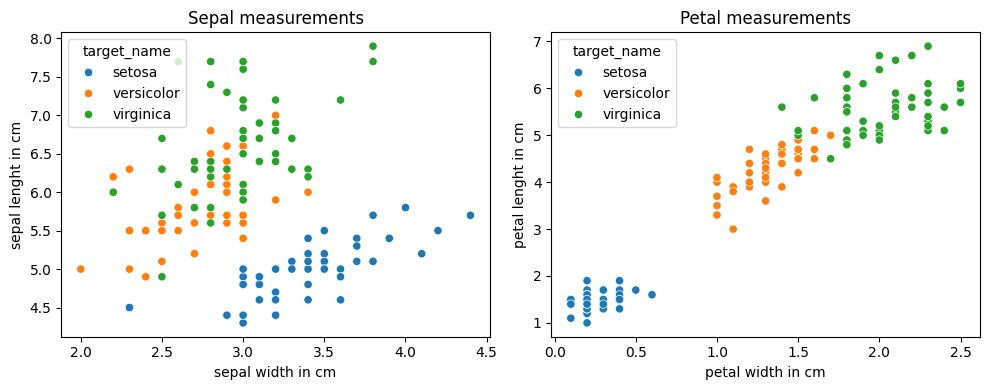

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: sepal measurements
sns.scatterplot(
    data=iris_data,
    x="sepal width in cm",
    y="sepal lenght in cm",
    hue="target_name",
    ax=axes[0]
)
axes[0].set_title("Sepal measurements")

# Right: petal measurements
sns.scatterplot(
    data=iris_data,
    x="petal width in cm",
    y="petal lenght in cm",
    hue="target_name",
    ax=axes[1]
)
axes[1].set_title("Petal measurements")

plt.tight_layout()
plt.show()

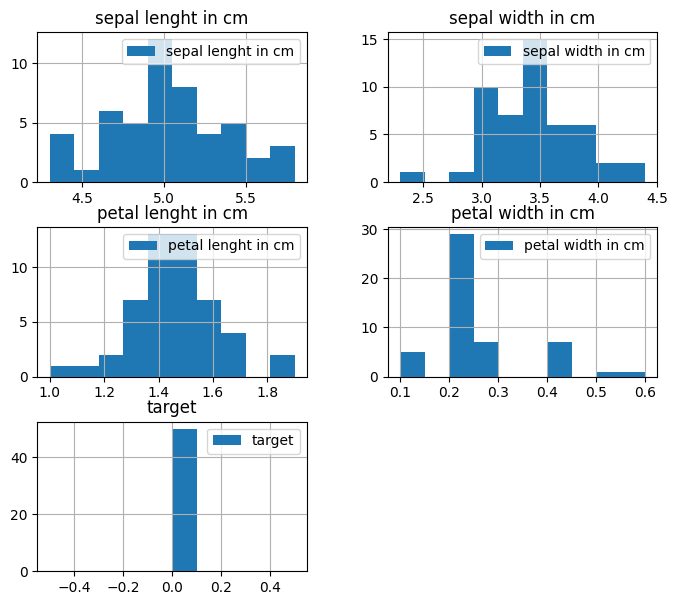

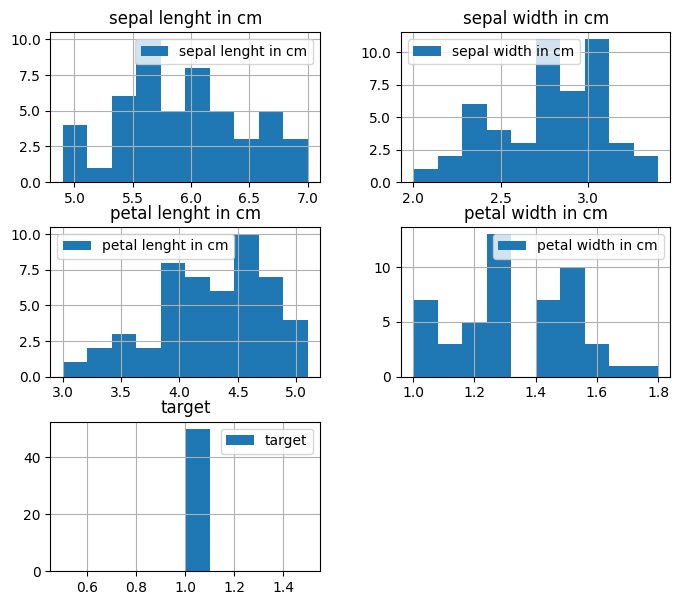

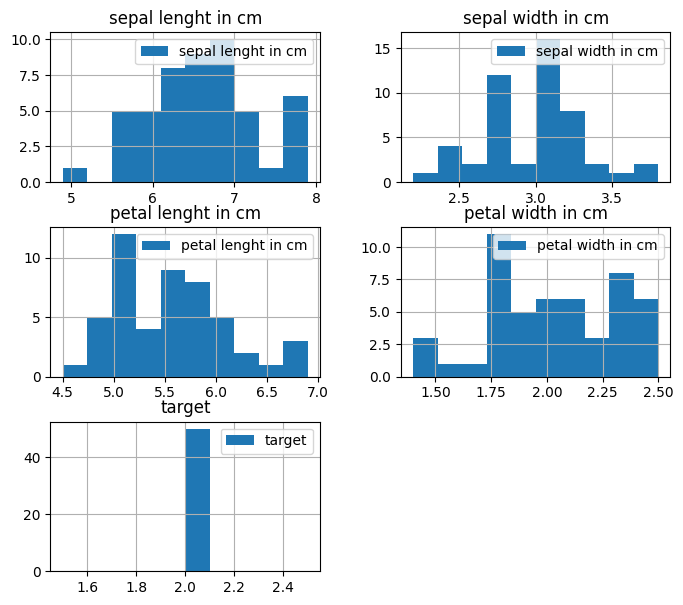

In [66]:
for i in range(3):
    iris_data[iris_data["target"] == i].hist(bins=10, legend=True, figsize=(8,7))

<Axes: xlabel='sepal area', ylabel='petal area'>

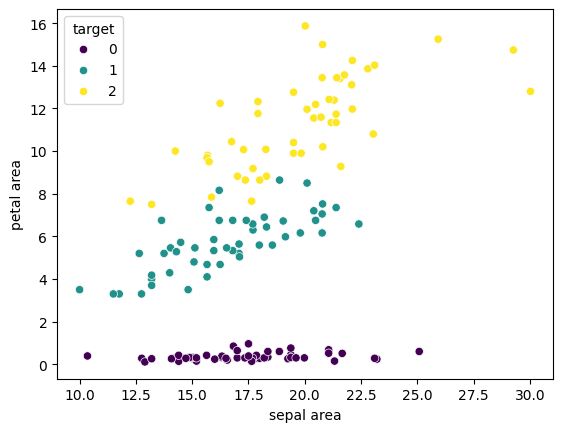

In [71]:
iris_data["sepal area"] = iris_data["sepal lenght in cm"] * iris_data["sepal width in cm"]
iris_data["petal area"] = iris_data["petal lenght in cm"] * iris_data["petal width in cm"]

sns.scatterplot(
    data=iris_data,
    x="sepal area",
    y="petal area",
    hue= "target",
    palette="viridis"
)

Text(0.5, 1.0, 'Correlation Heatmap')

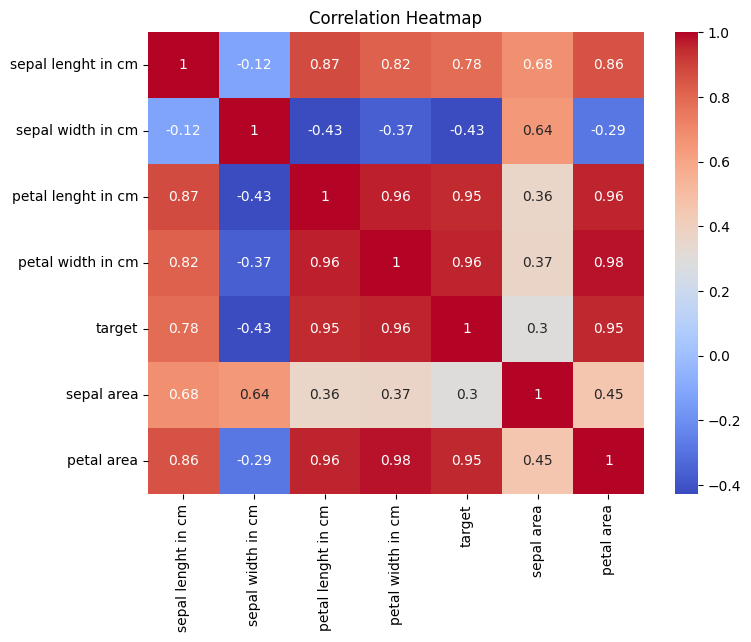

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(iris_data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

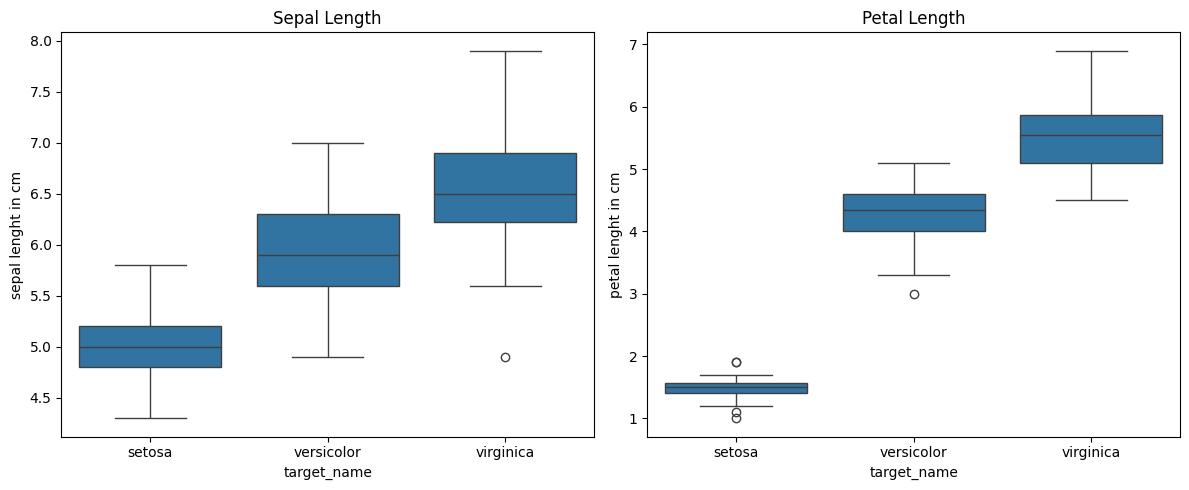

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=iris_data,
    x="target_name",
    y="sepal lenght in cm",
    ax=axes[0]
)
axes[0].set_title("Sepal Length")

sns.boxplot(
    data=iris_data,
    x="target_name",
    y="petal lenght in cm",
    ax=axes[1]
)
axes[1].set_title("Petal Length")

plt.tight_layout()

## 1. Split and scale data (*)

Do train|test split and scale the data using feature standardization, I used default test size 0.33 and random state 42. Check the mean and standard deviation on training and test data. 

---

In [99]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

X, y = iris_data.drop(["target", "target_name"], axis=1), iris_data["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("Scaled train mean:", np.mean(X_train_scaled, axis=0))
print("Scaled train std:", np.std(X_train_scaled, axis=0))

print("Scaled test mean:", np.mean(X_test_scaled, axis=0))
print("Scaled test std:", np.std(X_test_scaled, axis=0))


Scaled train mean: [ 3.72189052e-16  2.33146835e-16  4.22942105e-18 -2.28388736e-16
 -9.09325525e-17  8.03589999e-17]
Scaled train std: [1. 1. 1. 1. 1. 1.]
Scaled test mean: [ 0.00182999 -0.00550896  0.06502949  0.13666117  0.0043166   0.04373948]
Scaled test std: [0.82728687 0.79147574 0.82335589 0.93196957 0.81066227 0.86591301]


## 2. Classify with logistic regression (*)

Use k-folded cross-validation with logistic regression to find suitable hyperparameters and model. Check the documentation to see which parameters that can be chosen through cross-validation. Check the models parameters and see what it has chosen. 

<details>

<summary>Answer</summary>

weights: 

```py
array([[-1.33033256,  1.35076961, -2.26169407, -2.07715072],
       [ 0.40073538, -0.28598722, -0.58388865, -0.7782766 ],
       [ 0.67977172, -0.81485664,  3.09503329,  3.10542664]])
```

$\ell_1$-ratio:

```py
array([0.2, 0.2, 0.2])
```


<img src = "../data/pairplot_iris.png" height=300>

Do more EDA than I show here. 

d) Correlation heatmap

<img src = "../data/Correlation_iris.png" height=300>

The closer the value is to 1 between two features, the more positively linear relationships between them. The closer the value is to -1 the more negatively linear relationships between them. 

e) 

<img src = "../data/boxplot_iris.png" height=200>

f)
Outlier rows are: [13, 15, 22, 23, 24, 41, 43, 44, 98, 106, 117, 119, 131]

value counts:

|            |   specie_name |
|:-----------|--------------:|
| versicolor |            49 |
| virginica  |            46 |
| setosa     |            42 |

</details>

---

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])


score = cross_val_score(pipe, X, y, cv=5)

print(score)
print(score.mean())
print(score.std())

[0.96666667 1.         0.93333333 0.93333333 1.        ]
0.9666666666666668
0.029814239699997188


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.90      0.95      0.93        20
           2       0.92      0.85      0.88        13

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.94        45
weighted avg       0.93      0.93      0.93        45



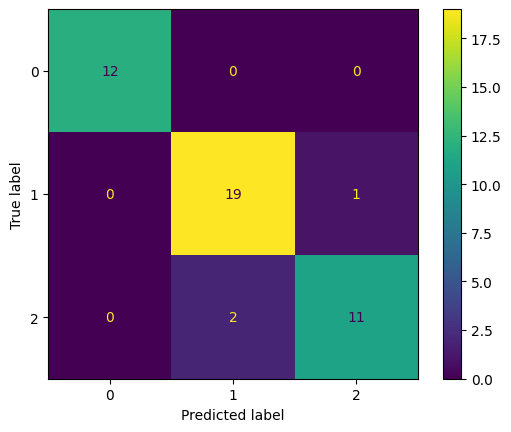

In [102]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

print(classification_report(y_test, pred))

ConfusionMatrixDisplay.from_predictions(y_test, pred)

## 3. Evaluate model (*)

Make a prediction on the testing data. 

&nbsp; a) Check manually the first 10 values of $y_{test}$ against your prediction. 

&nbsp; b) Plot a confusion matrix. Can you see which predictions the model have mispredicted?

&nbsp; c) Print a classification report 

<details>

<summary>Answer</summary>


b) 

<img src = "../data/confusion_matrix_iris.png" height=300>



c) 

Classification report 

```py
          precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        16
           2       0.94      1.00      0.97        16

    accuracy                           0.98        46
   macro avg       0.98      0.98      0.98        46
weighted avg       0.98      0.98      0.98        46
```






</details>

---

In [106]:
result = pd.DataFrame({"True class": y_test,
                       "predicted class" : pred})

print(result[result["True class"] != result["predicted class"]].size)
result.head(10)

6


,True class,predicted class
31,0,0
99,1,1
115,2,2
112,2,2
104,2,2
20,0,0
119,2,1
67,1,1
21,0,0
58,1,1


## 4. $k$-folded cross-validation for evaluation (**)

To be more robust in reporting the results, you should report the results as $\mu_{score}$, i.e. average score through a k-folded cross-validation. Report the score for precision, recall, f1-score for each label and overall accuracy. Do the cross-validation manually using for statement. 

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---